In [22]:
import sys
sys.path.insert(0, '../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

In [23]:
# %%
# Load TRFs for all subjects
SUBJECTS = helper_functions.fuglsang_get_subjects()

checks = [
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False),
]

cases = []

for subject in SUBJECTS:
    for predictor, attention, model, padded in checks:
        model_name = helper_functions.get_trf_model_name(DATASET_TYPE.FUGLSANG, predictor, attention, model, GENERALISATION_TYPE.INDIVIDUAL, padded)
        trf_path   = FUGLSANG_TRF_MAT_DIR / subject / f"{subject}_{model_name}_trf.pickle"

        if not trf_path.exists():
            print(f"Missing: {trf_path}, skipping.")
            continue

        trf                 = eelbrain.load.unpickle(trf_path)
        prediction_accuracy = trf.proportion_explained * 100
        h                   = trf.h[1] if isinstance(trf.h, tuple) else trf.h

        cases.append([subject, h, prediction_accuracy, attention.value, model_name])
        print(f"  ✓ Loaded {subject} | {model_name}")

data_trfs = eelbrain.Dataset.from_caselist(
    ['subject', 'trf', 'prediction_accuracy', 'attention', 'model'],
    cases,
    random='subject'
)

  ✓ Loaded S1 | forward_attended_envelope
  ✓ Loaded S1 | forward_ignored_envelope
  ✓ Loaded S1 | forward_attended_envelope_onset
  ✓ Loaded S1 | forward_ignored_envelope_onset
  ✓ Loaded S2 | forward_attended_envelope
  ✓ Loaded S2 | forward_ignored_envelope
  ✓ Loaded S2 | forward_attended_envelope_onset
  ✓ Loaded S2 | forward_ignored_envelope_onset
  ✓ Loaded S3 | forward_attended_envelope
  ✓ Loaded S3 | forward_ignored_envelope
  ✓ Loaded S3 | forward_attended_envelope_onset
  ✓ Loaded S3 | forward_ignored_envelope_onset
  ✓ Loaded S4 | forward_attended_envelope
  ✓ Loaded S4 | forward_ignored_envelope
  ✓ Loaded S4 | forward_attended_envelope_onset
  ✓ Loaded S4 | forward_ignored_envelope_onset
  ✓ Loaded S5 | forward_attended_envelope
  ✓ Loaded S5 | forward_ignored_envelope
  ✓ Loaded S5 | forward_attended_envelope_onset
  ✓ Loaded S5 | forward_ignored_envelope_onset
  ✓ Loaded S6 | forward_attended_envelope
  ✓ Loaded S6 | forward_ignored_envelope
  ✓ Loaded S6 | forward_att

In [24]:
# %%
# Sanity check
data_trfs

#,subject,attention,model
0,S1,attended,forward_attended_envelope
1,S1,ignored,forward_ignored_envelope
2,S1,attended,forward_attended_envelope_onset
3,S1,ignored,forward_ignored_envelope_onset
4,S2,attended,forward_attended_envelope
5,S2,ignored,forward_ignored_envelope
6,S2,attended,forward_attended_envelope_onset
7,S2,ignored,forward_ignored_envelope_onset
8,S3,attended,forward_attended_envelope
9,S3,ignored,forward_ignored_envelope


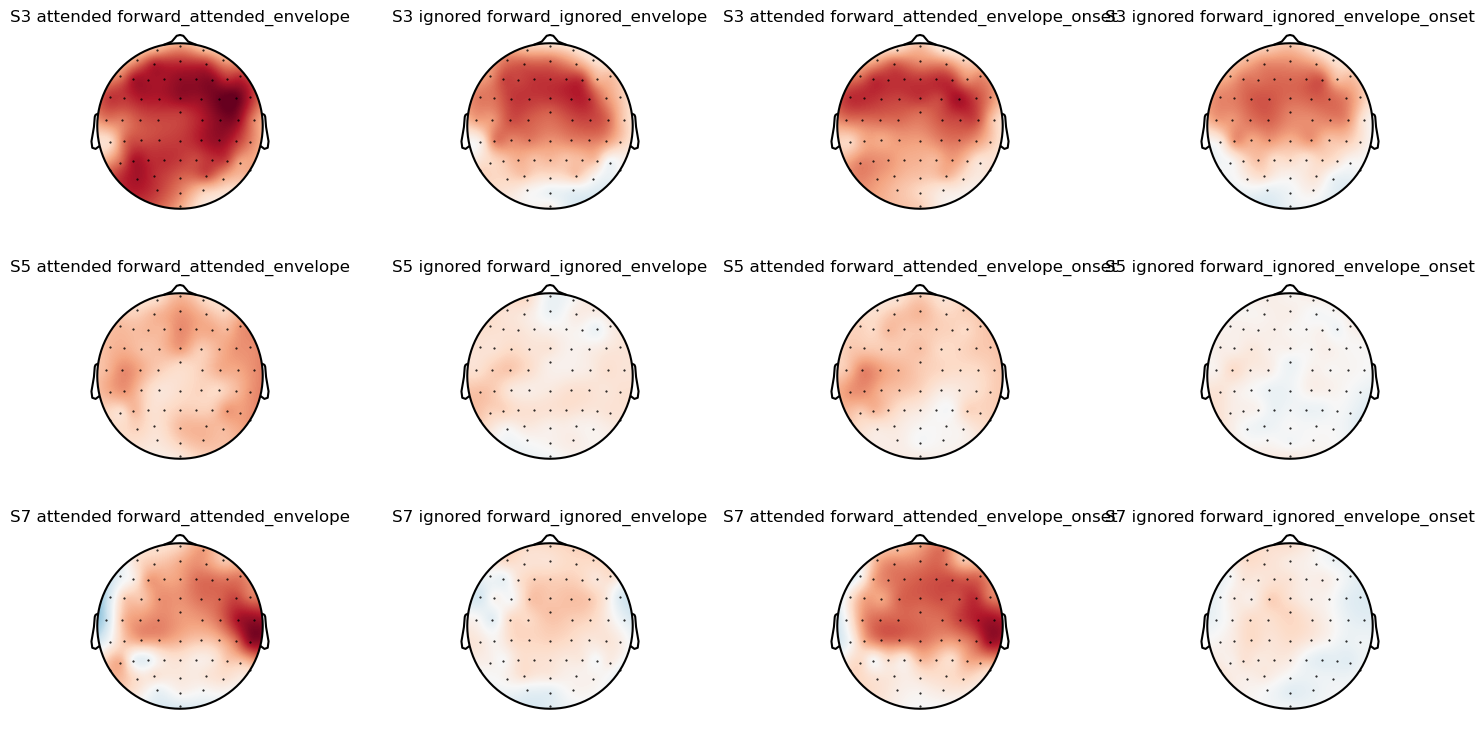

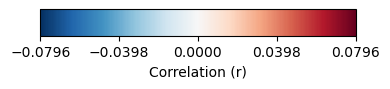

In [25]:
# %%
# Select subjects for topomap sanity check
subjects_to_plot = [3, 5, 7]
plots_flat       = []
titles           = []

for s in subjects_to_plot:
    for predictor, attention, model, padded in checks:
        model_name = helper_functions.get_trf_model_name(DATASET_TYPE.FUGLSANG, predictor, attention, model, GENERALISATION_TYPE.INDIVIDUAL, padded)
        trf_path   = FUGLSANG_TRF_MAT_DIR / SUBJECTS[s] / f"{SUBJECTS[s]}_{model_name}_trf.pickle"
        trf        = eelbrain.load.unpickle(trf_path)
        plots_flat.append(trf.r)
        titles.append(f"S{s} {attention.value} {model_name}")

all_data = np.concatenate([ndvar.x.flatten() for ndvar in plots_flat])
absmax   = np.max(np.abs(all_data))

p = eelbrain.plot.Topomap(
    plots_flat,
    axtitle=titles,
    cmap='RdBu_r',
    vmin=-absmax,
    vmax=absmax,
    clip='circle',
    columns=len(checks),
    margins=dict(hspace=0.5, wspace=1.5),
)
p.plot_colorbar(label="Correlation (r)", ticks=5)
fig = p.figure
fig.savefig(FUGLSANG_FIGURES_DIR / f'fuglsang-topomaps.pdf', dpi=300)

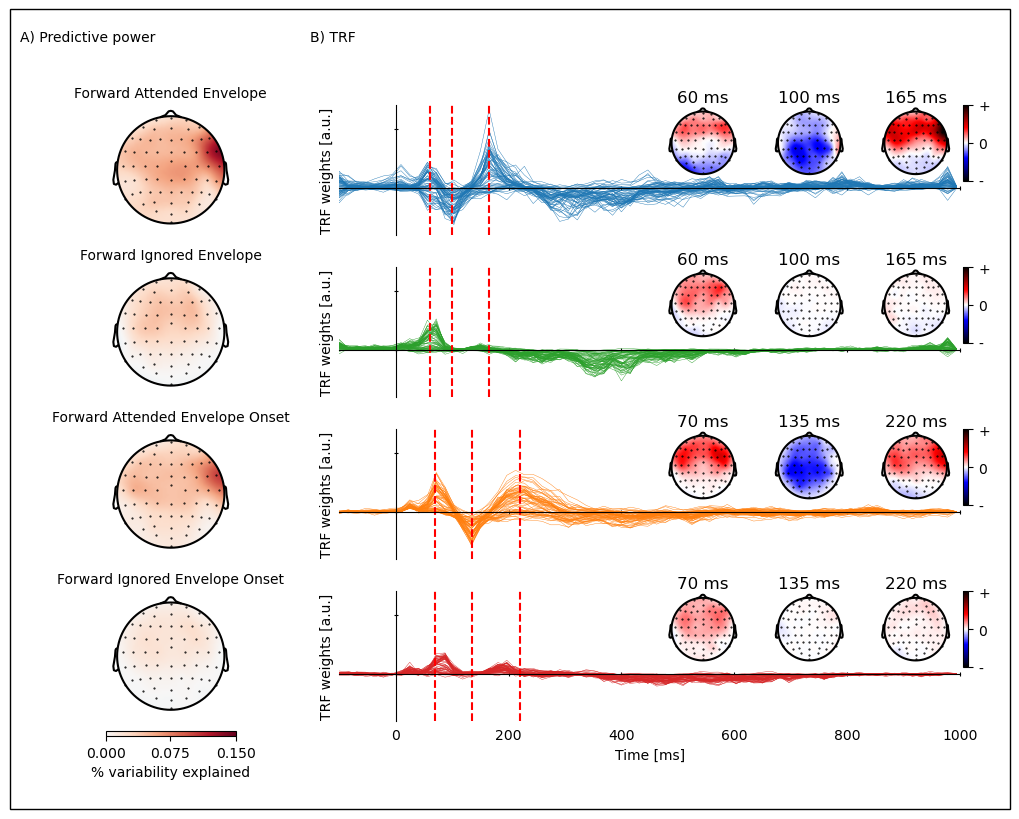

In [26]:
# %%
# Main figure
figure    = plt.figure(figsize=(10, 8))
gridspec  = figure.add_gridspec(12, 9, left=0.01, right=0.95, hspace=1.5)
topo_args = dict(clip='circle')
det_args = dict(**topo_args, cmap='RdBu_r', vmax=0.15)
trf_vmax  = 0.007
colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']

last_topo_p    = None
last_topo_axes = None

for idx, (predictor, attention, model, padded) in enumerate(checks):
    model_name = helper_functions.get_trf_model_name(DATASET_TYPE.FUGLSANG, predictor, attention, model, GENERALISATION_TYPE.INDIVIDUAL, padded)
    label      = model_name.replace('_', ' ').title()
    mask       = data_trfs['model'] == model_name

    # A) Prediction accuracy topomap
    topo_axes_a = figure.add_subplot(gridspec[idx*3: idx*3+3, 0:3])
    last_topo_p = eelbrain.plot.Topomap('prediction_accuracy', data=data_trfs[mask], axes=topo_axes_a, **det_args)
    topo_axes_a.set_title(label, loc='center', size=10)
    last_topo_axes = topo_axes_a

    # B) Butterfly TRF
    trf    = data_trfs[mask, 'trf']
    times  = [0.06, 0.100, 0.165] if predictor == PREDICTOR_TYPE.ENVELOPE else [0.07, 0.135, 0.220]
    t_labels = ['%d ms' % (t * 1000) for t in times]

    axes   = figure.add_subplot(gridspec[idx*3: idx*3+3, 3:9])
    kwargs = dict(vmin=-0.004, vmax=0.007, linewidth=0.3, color=colors[idx],
                  ylabel='TRF weights [a.u.]', frame='t', yticklabels='none',
                  xlim=(-0.100, 1.000), clip=True)
    if idx != len(checks) - 1:
        kwargs.update(dict(xticklabels='none', xlabel=''))
    plot = eelbrain.plot.Butterfly(trf, axes=axes, **kwargs)
    for t in times:
        plot.add_vline(t, color='r', linestyle='--')

    # Topomaps at selected times
    topo_axes = [figure.add_subplot(gridspec[idx*3: idx*3+2, 6 + i]) for i in range(3)]
    plot_topo = eelbrain.plot.Topomap(
        [trf.sub(time=t) for t in times],
        axes=topo_axes, axtitle=t_labels, columns=3, vmax=trf_vmax, **topo_args
    )
    plot_topo.plot_colorbar(
        right_of=topo_axes[-1], label='', label_rotation=90,
        ticks={trf_vmax: '+', -trf_vmax: '-', 0: '0'}
    )

# Colorbar below the last prediction accuracy topomap
last_topo_p.plot_colorbar(below=last_topo_axes, label="% variability explained", clipmin=0, ticks=5, h=2)

figure.text(0.01, 0.96, 'A) Predictive power', size=10)
figure.text(0.30, 0.96, 'B) TRF', size=10)
figure.savefig(FUGLSANG_FIGURES_DIR / f'fuglsang-topo-butterflies.pdf')
eelbrain.plot.figure_outline()